In [26]:
n = int(10)
m = int(10)
eps = float(1.0)
M=[]
for i in range(0,10):
    M.append([])
    for j in range(0,10):
        M[i].append(abs(n-1-2*j + m-1-2*i)+1)
show(matrix(M))

[19 17 15 13 11  9  7  5  3  1]
[17 15 13 11  9  7  5  3  1  3]
[15 13 11  9  7  5  3  1  3  5]
[13 11  9  7  5  3  1  3  5  7]
[11  9  7  5  3  1  3  5  7  9]
[ 9  7  5  3  1  3  5  7  9 11]
[ 7  5  3  1  3  5  7  9 11 13]
[ 5  3  1  3  5  7  9 11 13 15]
[ 3  1  3  5  7  9 11 13 15 17]
[ 1  3  5  7  9 11 13 15 17 19]

In [49]:
import ctypes

class_lib = ctypes.CDLL("./class_lib.so")

class_lib.max_search.argtypes = [ctypes.c_int, ctypes.c_int, ctypes.POINTER(ctypes.c_double)]
class_lib.max_search.restype = ctypes.c_double

class_lib.slice_graph.argtypes = [ctypes.c_int, ctypes.c_int, ctypes.c_double, ctypes.POINTER(ctypes.c_double), ctypes.POINTER(ctypes.c_int)]
class_lib.slice_graph.restype = ctypes.c_int

n = int(10)
m = int(10)
eps = float(1.0)
round_to = 1


        
maximum = class_lib.max_search(n,m,M)
k = int((maximum/eps) + 1)
sequence_graphs = []
sequence_connected_components={}
l = 0.0

coords={}
for x in range(n*m):
    coords[x] = (x%m, -int(x/m))
    
while l < maximum: 
    gr_con = (ctypes.c_int * (int(2*n*m*2)))()
    gr_con_len = class_lib.slice_graph(n, m, l, M, gr_con)
    gr_con_to_py = [(gr_con[2*i], gr_con[2*i+1]) for i in range(gr_con_len)]
    sequence_graphs.append(gr_con_to_py)
    sequence_connected_components[round(l,round_to)]=Graph(gr_con_to_py).connected_components_number()
    l += eps
show(sequence_connected_components)

{0.0: 1,
 1.0: 2,
 2.0: 2,
 3.0: 2,
 4.0: 2,
 5.0: 2,
 6.0: 2,
 7.0: 2,
 8.0: 2,
 9.0: 2,
 10.0: 2,
 11.0: 2,
 12.0: 2,
 13.0: 2,
 14.0: 2,
 15.0: 2,
 16.0: 2,
 17.0: 0,
 18.0: 0}

In [32]:
M=(ctypes.c_double * int(n*m))()
for i in range(10):
    for j in range(10):
        M[i*m+j] = abs(n-2*j + m-2*i-2)+1
M_remat = [[M[i*m + j] for j in range(m)] for i in range(n)]
show(matrix(M_remat))

[19.0 17.0 15.0 13.0 11.0  9.0  7.0  5.0  3.0  1.0]
[17.0 15.0 13.0 11.0  9.0  7.0  5.0  3.0  1.0  3.0]
[15.0 13.0 11.0  9.0  7.0  5.0  3.0  1.0  3.0  5.0]
[13.0 11.0  9.0  7.0  5.0  3.0  1.0  3.0  5.0  7.0]
[11.0  9.0  7.0  5.0  3.0  1.0  3.0  5.0  7.0  9.0]
[ 9.0  7.0  5.0  3.0  1.0  3.0  5.0  7.0  9.0 11.0]
[ 7.0  5.0  3.0  1.0  3.0  5.0  7.0  9.0 11.0 13.0]
[ 5.0  3.0  1.0  3.0  5.0  7.0  9.0 11.0 13.0 15.0]
[ 3.0  1.0  3.0  5.0  7.0  9.0 11.0 13.0 15.0 17.0]
[ 1.0  3.0  5.0  7.0  9.0 11.0 13.0 15.0 17.0 19.0]

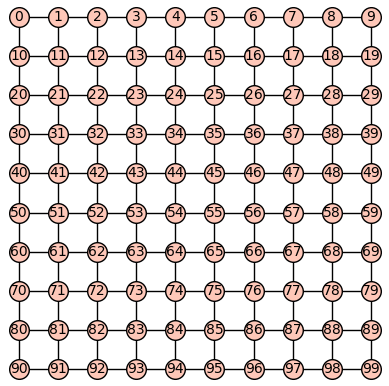

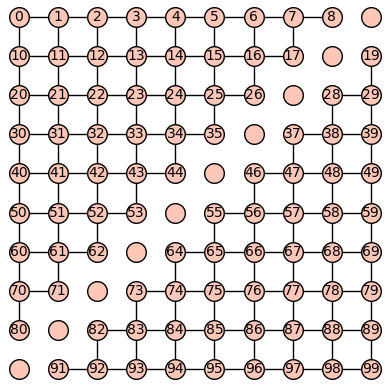

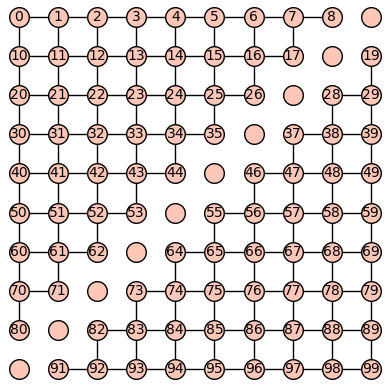

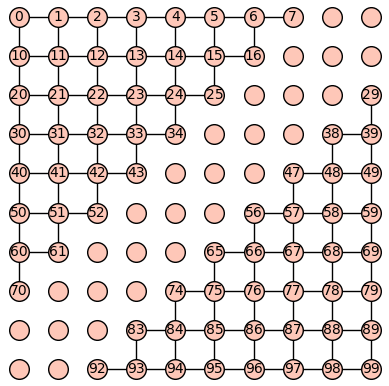

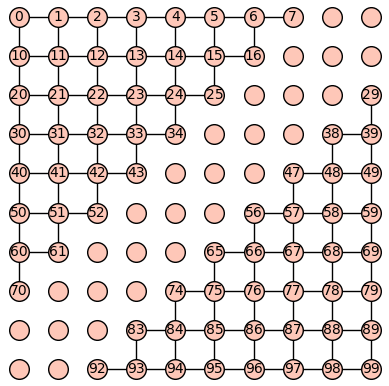

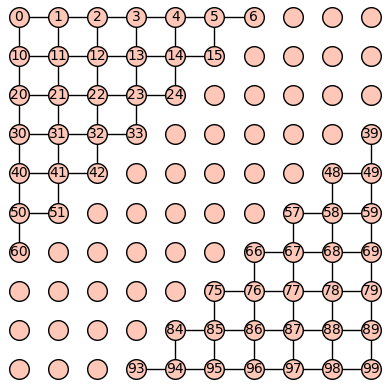

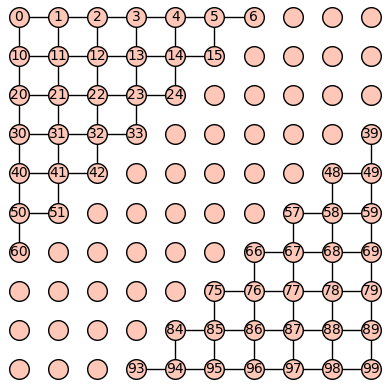

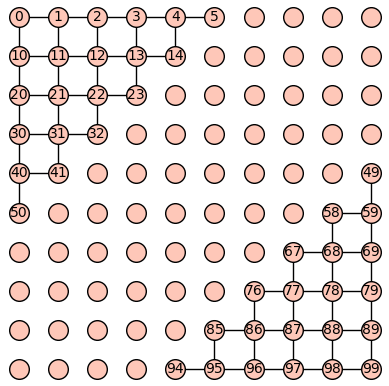

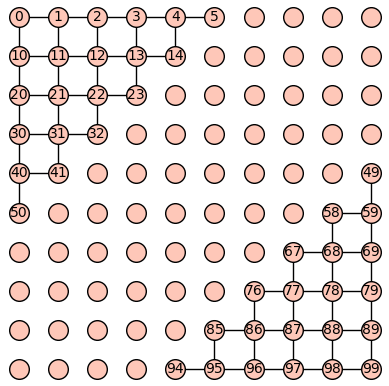

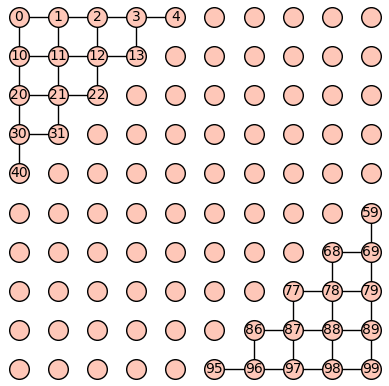

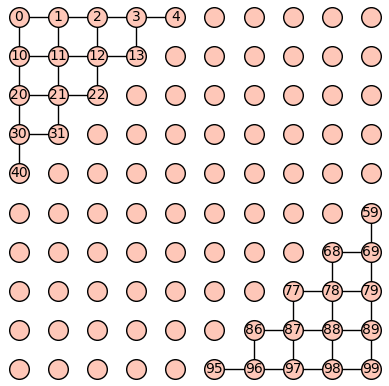

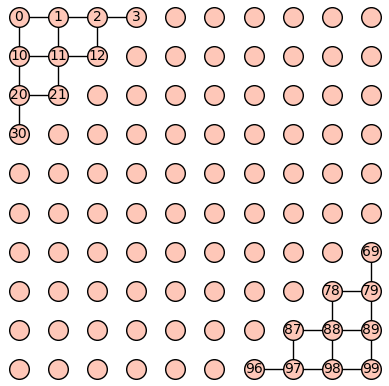

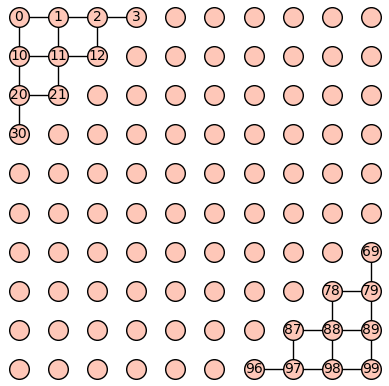

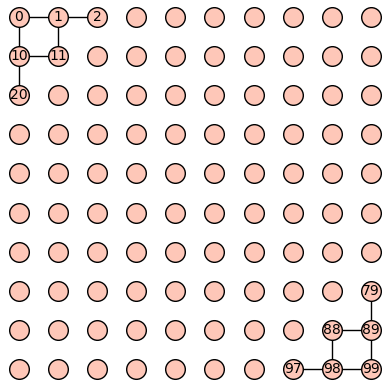

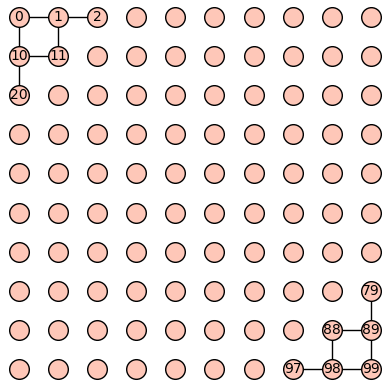

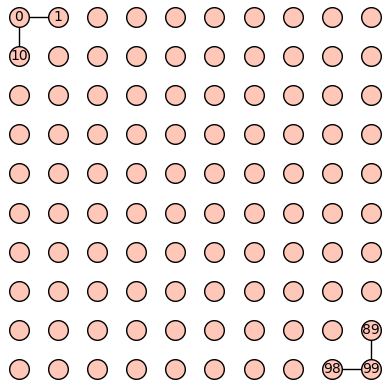

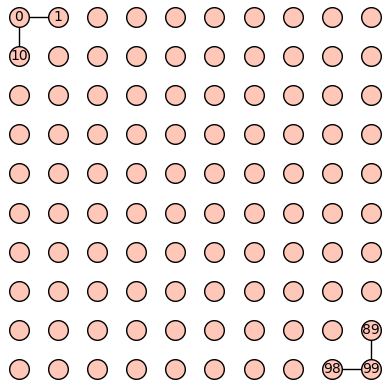

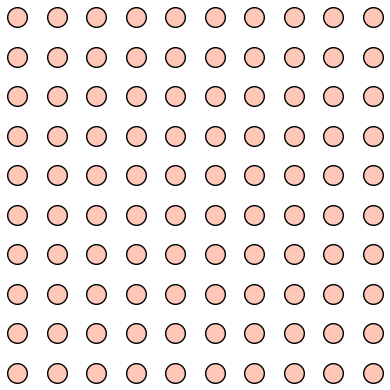

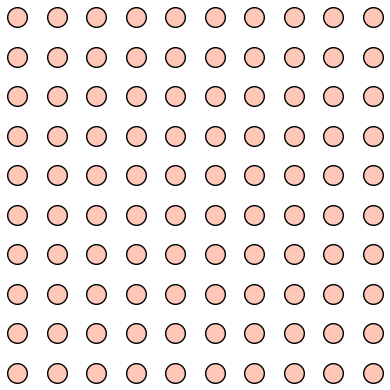

In [50]:
for a in sequence_graphs:
    Graph(a).show(pos = coords)